Fourier Transform in Images

The Fourier Transform (FT) is a mathematical tool that decomposes a signal (such as an image) into sine and cosine components. It helps analyze frequency components of an image.

1. Low frequencies: Represent smooth variations (gradual intensity changes).
2. High frequencies: Represent rapid variations (edges, sharp transitions).

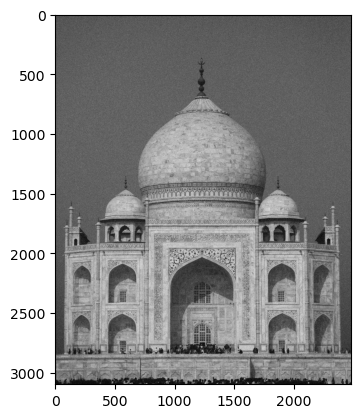

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# load image
img = cv2.imread('ImageEnhancement/taj_grey.jpg', cv2.IMREAD_GRAYSCALE)
plt.imshow(img, cmap='gray')

/tmp/ipykernel_3061/4087343125.py:3: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  plt.hist(img.flatten(), 256, [0, 256])


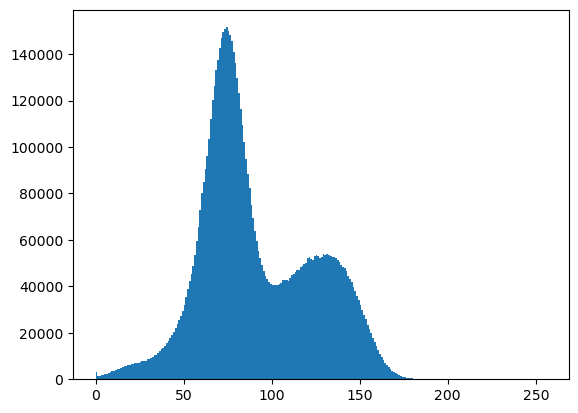

In [3]:
# view histogram
plt.figure()
plt.hist(img.flatten(), 256, [0, 256])
plt.show()


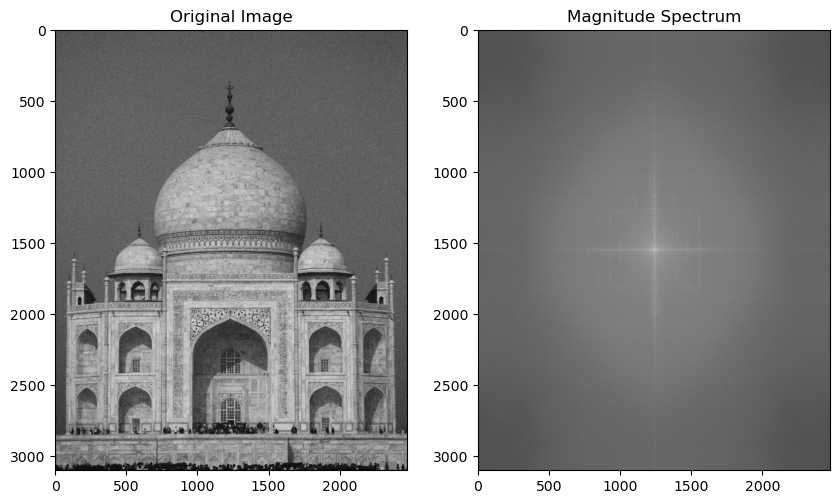

In [ ]:
    # apply 2d fourier transform
    f_transform = np.fft.fft2(img)
    f_transform_shift = np.fft.fftshift(f_transform)
    # magnitude spectrum
    magnitude_spectrum = 20 * np.log(np.abs(f_transform_shift))

    # display magnitude spectrum
    plt.figure(figsize=(10, 10))
    plt.subplot(121), plt.imshow(img, cmap='gray') , plt.title('Original Image')
    plt.subplot(122), plt.imshow(magnitude_spectrum, cmap='gray') , plt.title('Magnitude Spectrum')
    plt.show()

In [8]:
rows ,cols = img.shape
crow, ccol = rows//2 , cols//2 # center
# create a mask first, center square is 1, remaining all zeros
mask = np.zeros((rows, cols), np.uint8)
radius = 50
# mask[crow-radius:crow+radius, ccol-radius:ccol+radius] = 1
cv2.circle(mask,(ccol,crow),radius,1,thickness=-1)

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], dtype=uint8)

/tmp/ipykernel_3061/105982760.py:7: RuntimeWarning: divide by zero encountered in log
  plt.subplot(132), plt.imshow(20 * np.log(np.abs(low_pass_filter)), cmap='gray') , plt.title('Low Pass Filter * 20')
/tmp/ipykernel_3061/105982760.py:8: RuntimeWarning: divide by zero encountered in log
  plt.subplot(133), plt.imshow(np.log(np.abs(low_pass_filter)), cmap='gray') , plt.title('Low Pass Filter')


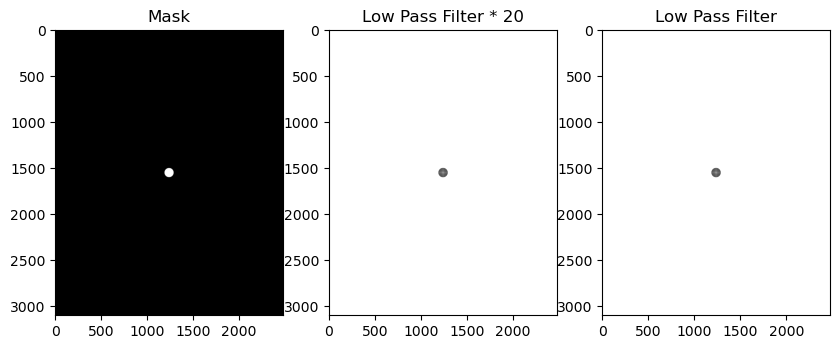

In [12]:
# law pass filter
low_pass_filter = f_transform_shift * mask

#  display low pass filter
plt.figure(figsize=(10, 10))
plt.subplot(131), plt.imshow(mask, cmap='gray') , plt.title('Mask')
plt.subplot(132), plt.imshow(20 * np.log(np.abs(low_pass_filter)), cmap='gray') , plt.title('Low Pass Filter * 20')
plt.subplot(133), plt.imshow(np.log(np.abs(low_pass_filter)), cmap='gray') , plt.title('Low Pass Filter')
plt.show()

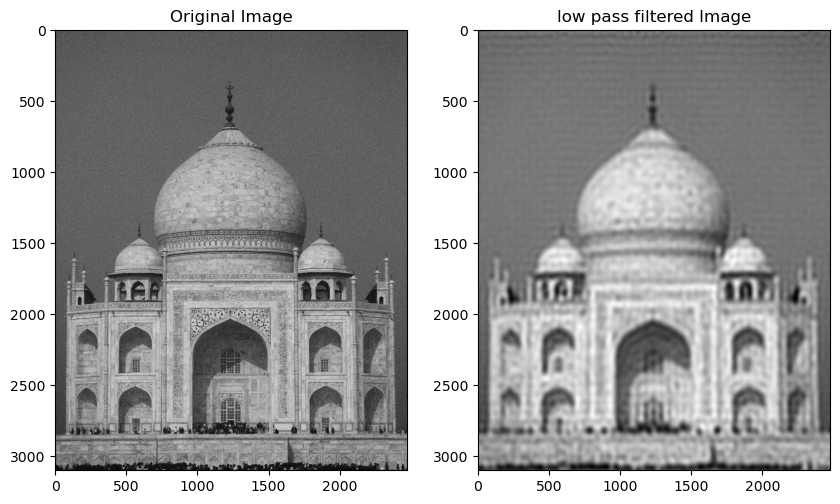

In [14]:
low_pass_filtered_shifted = np.fft.ifftshift(low_pass_filter)
#  inverse fourier transform
restored_image = np.fft.ifft2(low_pass_filtered_shifted)
restored_image = np.abs(restored_image)

# display restored image
plt.figure(figsize=(10, 10))
plt.subplot(121), plt.imshow(img, cmap='gray') , plt.title('Original Image')
plt.subplot(122), plt.imshow(restored_image, cmap='gray') , plt.title('low pass filtered Image')
plt.show()

/tmp/ipykernel_3061/2187939836.py:7: RuntimeWarning: divide by zero encountered in log
  plt.subplot(133), plt.imshow(np.log(np.abs(high_pass_filter)), cmap='gray') , plt.title('High Pass Filter')


(<Axes: title={'center': 'High Pass Filter'}>,
 Text(0.5, 1.0, 'High Pass Filter'))

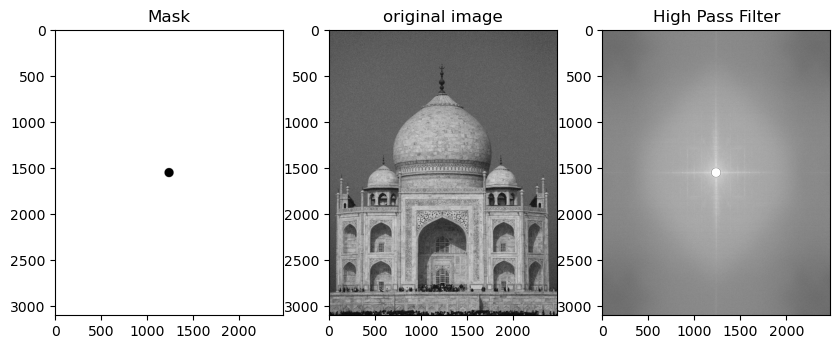

In [16]:
# create high pass filter
high_pass_filter = f_transform_shift * (1-mask)
# display high pass filter
plt.figure(figsize=(10, 10))
plt.subplot(131), plt.imshow(1-mask, cmap='gray') , plt.title('Mask')
plt.subplot(132), plt.imshow(img, cmap='gray') , plt.title('original image')
plt.subplot(133), plt.imshow(np.log(np.abs(high_pass_filter)), cmap='gray') , plt.title('High Pass Filter')

(<Axes: title={'center': 'Edge Image'}>,
 Text(0.5, 1.0, 'Edge Image'))

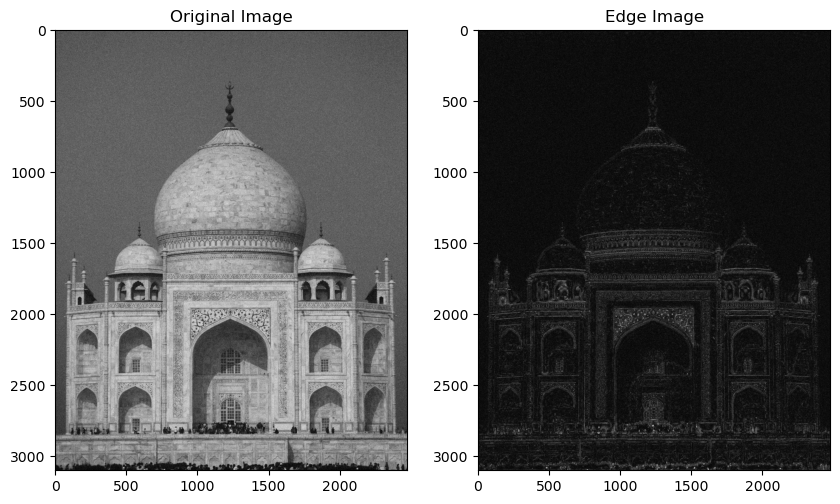

In [ ]:
# shift back
high_pass_filtered_shifted = np.fft.ifftshift(high_pass_filter)
# inverse fourier transform
edge_image = np.fft.ifft2(high_pass_filtered_shifted)
edge_image = np.abs(edge_image)
#  display edge image
plt.figure(figsize=(10, 10))
plt.subplot(121), plt.imshow(img, cmap='gray') , plt.title('Original Image')
plt.subplot(122), plt.imshow(edge_image, cmap='gray') , plt.title('Edge Image')
plt.show()